In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [141]:
df = pd.read_csv("Customer Churn.csv")

In [142]:
df.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [143]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [145]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [147]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [148]:
df["customerID"].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: customerID, Length: 7043, dtype: bool

In [149]:
def conv(value):
    if value == 1:
        return "Yes"
    else: 
        return "No"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

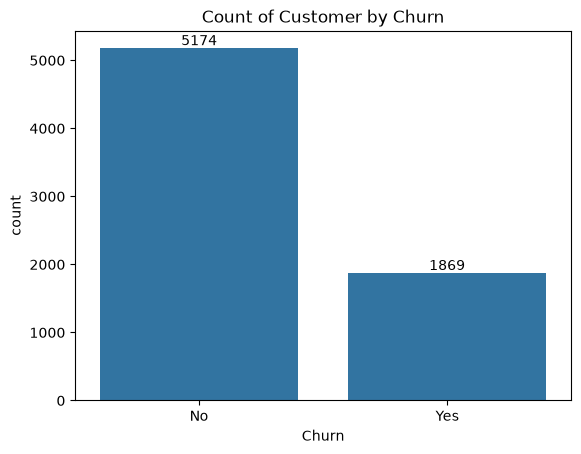

In [150]:
ax = sns.countplot(data=df, x='Churn')

ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Churn")
plt.show()

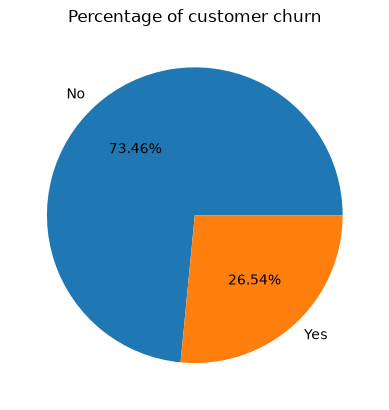

In [151]:
gb = df.groupby("Churn").agg({'Churn': 'count'})

plt.pie(gb['Churn'], labels=gb.index, autopct="%1.2f%%")
plt.title("Percentage of customer churn")
plt.show()

From the give pie chart we can conclude that 26.54% of out customer are churned out

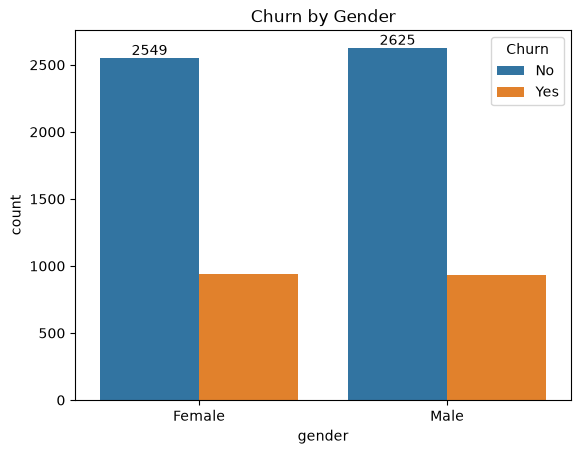

In [152]:
plt.Figure(figsize=(4,3))
ax = sns.countplot(x="gender", data=df, hue='Churn')

ax.bar_label(ax.containers[0])
plt.title("Churn by Gender")
plt.show()

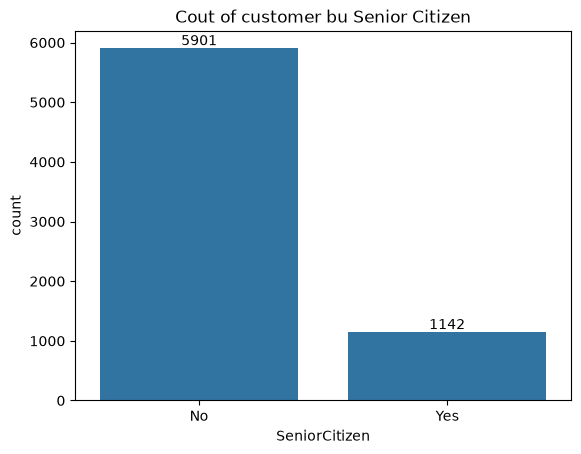

In [153]:
plt.Figure(figsize=(4,3))
ax = sns.countplot(x="SeniorCitizen", data=df)

ax.bar_label(ax.containers[0])
plt.title("Cout of customer bu Senior Citizen")
plt.show()

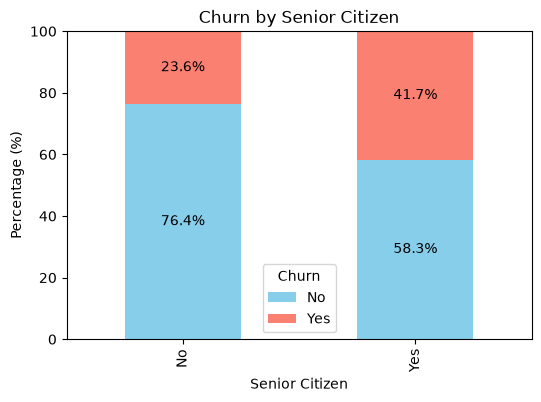

In [154]:
# Create a cross-tabulation
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Convert counts to percentages
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot 100% stacked bar chart
ax = ct_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4),
    color=['skyblue', 'salmon']
)

# Add percentage labels
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10)

plt.title('Churn by Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn')
plt.ylim(0, 100)

plt.show()

Comparative a greated percentage of people in senior citizen category have churnned out

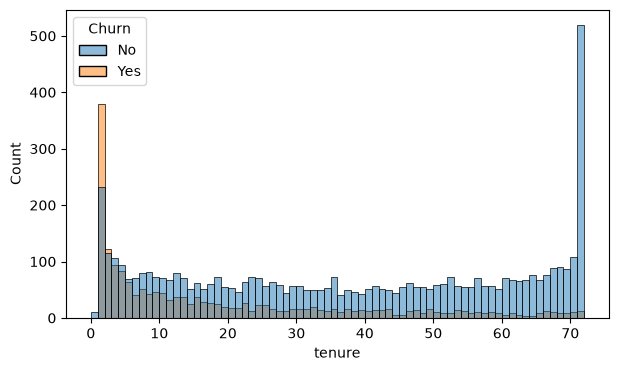

In [155]:
plt.figure(figsize=(7,4))
sns.histplot(x='tenure', data=df, bins=72, hue='Churn')
plt.show()

Perople who have used for a long time have stayed and people who have used our services for 1 or 2 months have churned out

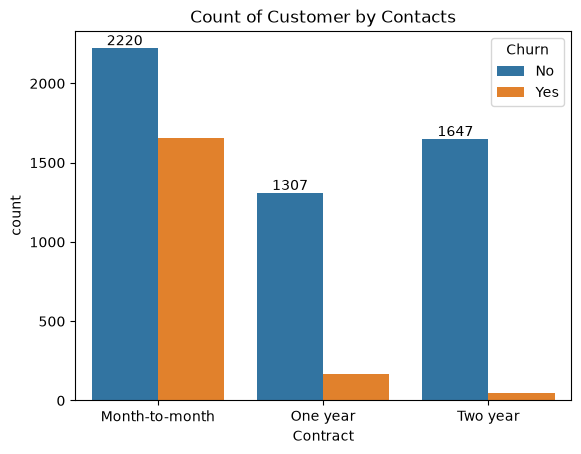

In [156]:
plt.Figure(figsize=(5,4))
ax = sns.countplot(x="Contract", data=df, hue='Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Contacts")
plt.show()

Insights

📌 Insight 1

Customers with Month-to-month contracts are significantly more likely to churn than customers with longer-term contracts.

📌 Insight 2

Customers on One-year and Two-year contracts show much higher retention, indicating that longer commitments reduce customer churn.

📌 Insight 3

The Two-year contract has the highest customer loyalty, with only a small percentage of customers leaving.

📌 Business Recommendation

The company should encourage Month-to-month customers to switch to One-year or Two-year plans by offering:

Discounted pricing
Loyalty rewards
Bundled services
Exclusive long-term benefits

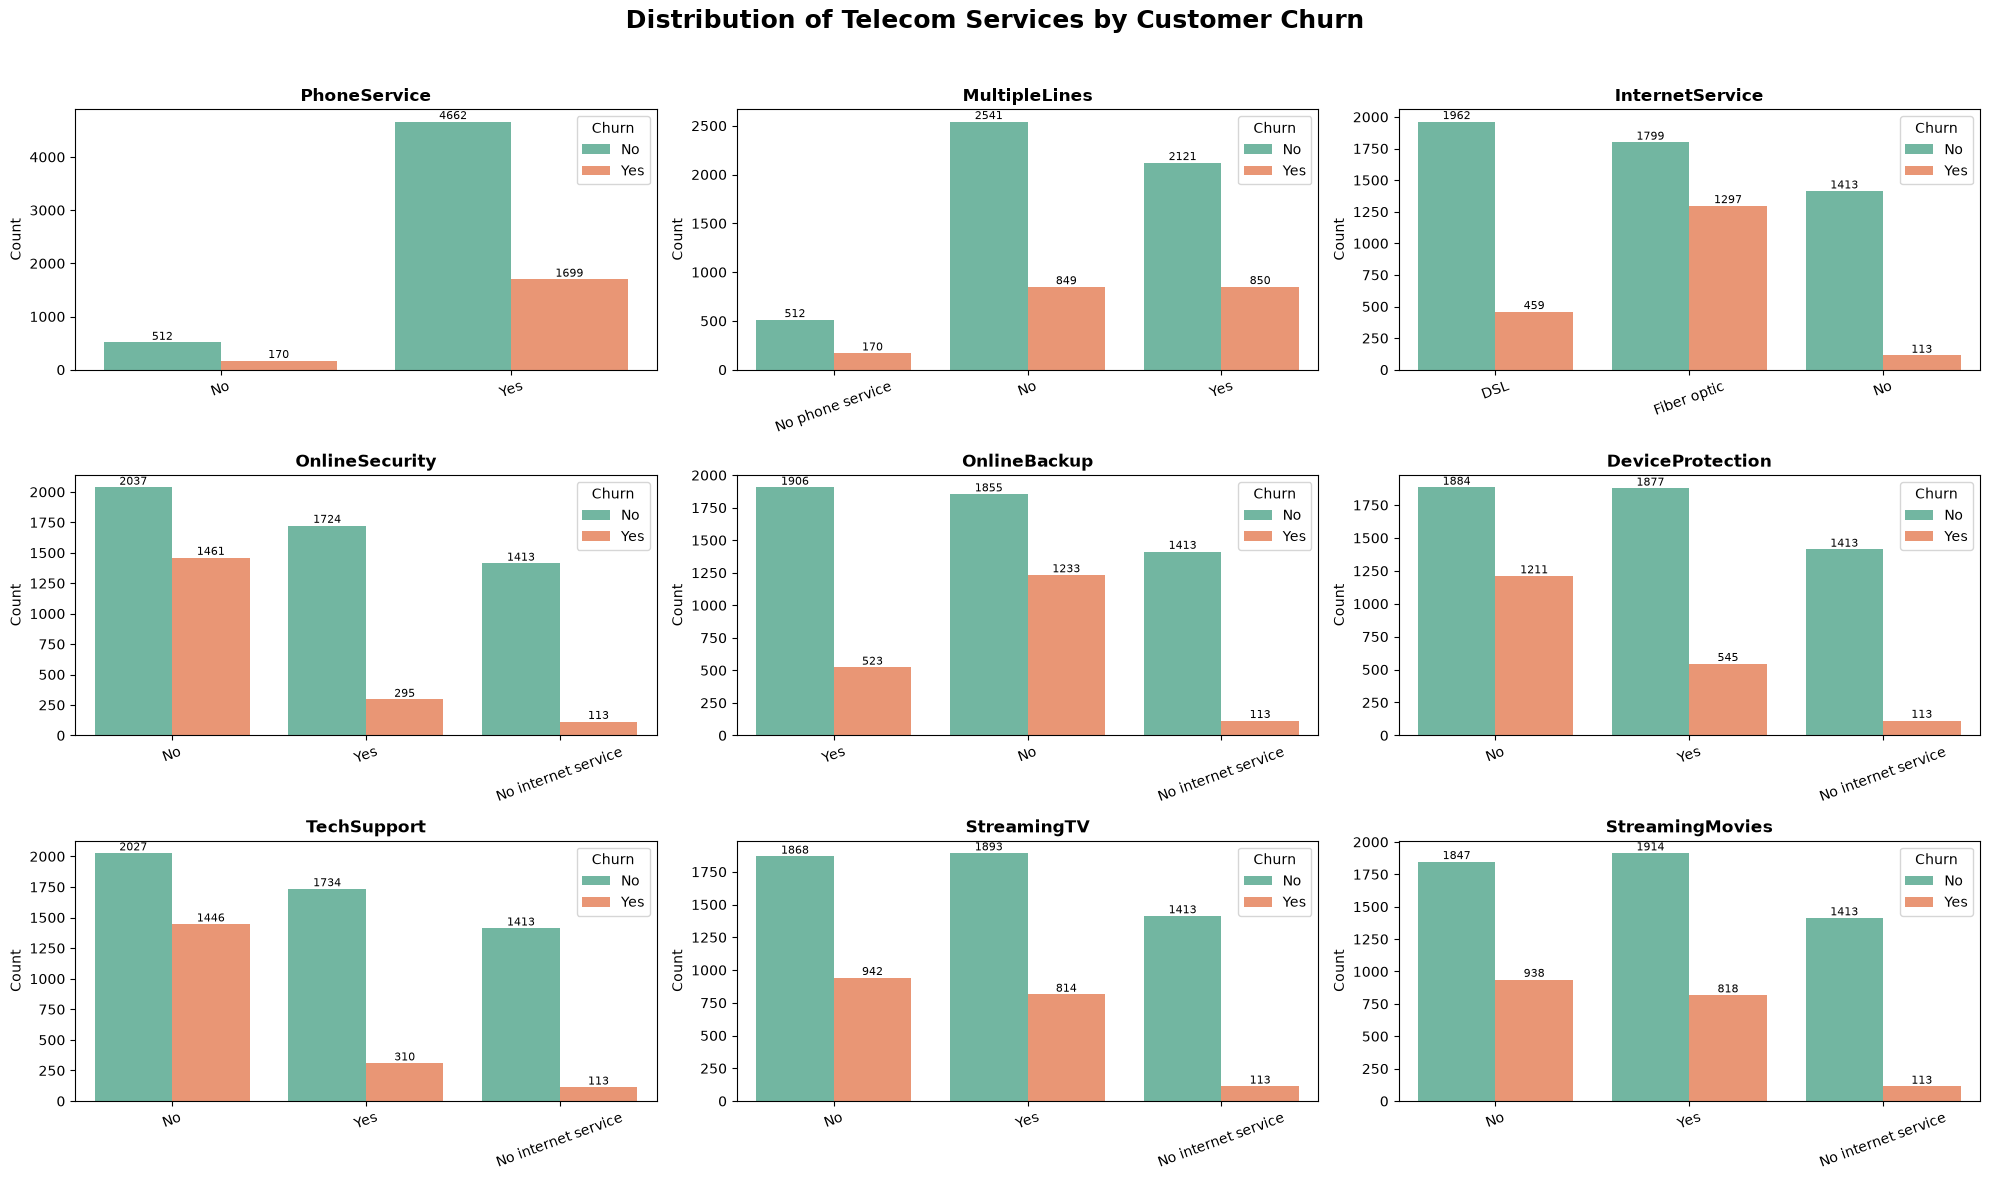

In [157]:
cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        palette='Set2',
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=20)

    for container in axes[i].containers:
        axes[i].bar_label(container, fontsize=8)

plt.suptitle(
    "Distribution of Telecom Services by Customer Churn",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The majority of customer who do not churn tend to have service like phoneservice, internetservice, (particularly DSL), and OnlineSecurity enabled. For Service like Onlinesupport, TechSupport and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable  

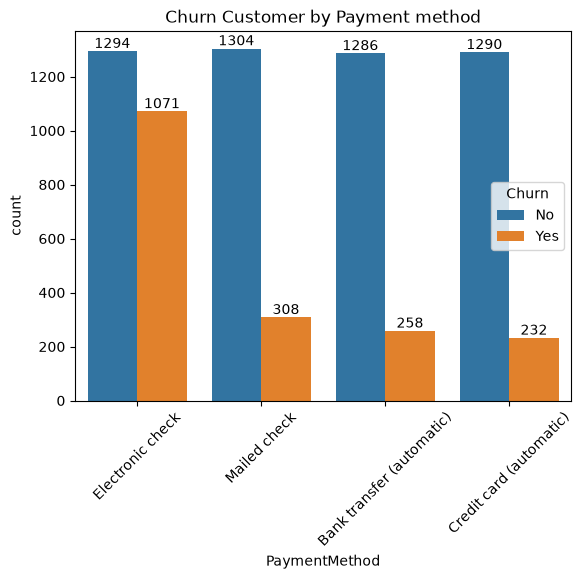

In [158]:
plt.Figure(figsize=(5,5))
ax = sns.countplot(data=df, x='PaymentMethod', hue='Churn')

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn Customer by Payment method")
plt.xticks(rotation = 45)
plt.show()

Customer is likely to churn when he is using electronic check as payment method.